<a href="https://colab.research.google.com/github/Vigneshvicky13/FORGE_GYM/blob/main/Credit_Risk_Prediction_System_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
df = pd.read_excel("raw-lending-club-loans.xlsx", skiprows=1)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599.0,5000.0,5000.0,4975.0,36 months,0.1065,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167.0,2500.0,2500.0,2500.0,60 months,0.1527,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524.0,2400.0,2400.0,2400.0,36 months,0.1596,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178.0,10000.0,10000.0,10000.0,36 months,0.1349,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748.0,3000.0,3000.0,3000.0,60 months,0.1269,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [ ]:
print("Total rows:", df.shape[0])

Total rows: 42542


In [ ]:
df.duplicated().any()

np.True_

In [ ]:
df.duplicated(subset=['id']).any()

np.True_

In [ ]:
df.duplicated(subset=['id']).sum()

np.int64(3)

In [ ]:
df[df.duplicated(subset=['id'], keep=False)]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
39786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.drop_duplicates(subset=['id'], keep='first')

In [ ]:
print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 42539


In [ ]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42542 entries, 0 to 42541
Columns: 115 entries, id to total_il_high_credit_limit
dtypes: datetime64[ns](5), float64(92), object(18)
memory usage: 37.3+ MB


,0
id,4
member_id,7
loan_amnt,7
funded_amnt,7
funded_amnt_inv,7
...,...
tax_liens,112
tot_hi_cred_lim,42542
total_bal_ex_mort,42542
total_bc_limit,42542


In [ ]:
drop_list = [
    'id','member_id','funded_amnt','funded_amnt_inv',
    'sub_grade','emp_title','issue_d','zip_code',
    'out_prncp','out_prncp_inv','url','desc','total_pymnt','total_pymnt_inv',
    'total_rec_prncp','total_rec_int','total_rec_late_fee',
    'recoveries','collection_recovery_fee','last_pymnt_d',
    'last_pymnt_amnt'
]

df.drop(columns=drop_list, inplace=True, errors='ignore')

In [ ]:
# Numeric
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("Missing")

In [ ]:
if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].astype(str).str.extract(r'(\d+)')
    df['emp_length'] = df['emp_length'].fillna(0).astype(float)

if 'int_rate' in df.columns:
    df['int_rate'] = df['int_rate'].astype(str).str.replace('%','')
    df['int_rate'] = df['int_rate'].astype(float)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}   # ✅ create dictionary

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le   # ✅ store encoder

In [ ]:
# Drop columns with more than 50% missing values
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(df.median())

print("Remaining NaN:", df.isnull().sum().sum())

Remaining NaN: 425390


In [ ]:
for col in df.columns:
 if (len(df[col].unique()) < 3):
    print(df[col].value_counts())

initial_list_status
f          42535
Missing        4
Name: count, dtype: int64
collections_12_mths_ex_med
0.0    42539
Name: count, dtype: int64
policy_code
1.0    42539
Name: count, dtype: int64
application_type
INDIVIDUAL    42535
Missing           4
Name: count, dtype: int64
acc_now_delinq
0.0    42535
1.0        4
Name: count, dtype: int64
chargeoff_within_12_mths
0.0    42539
Name: count, dtype: int64
tax_liens
0.0    42538
1.0        1
Name: count, dtype: int64


In [ ]:
target = 'loan_status'

X = df.drop(target, axis=1)
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
error = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error.append(np.mean(pred != y_test))

plt.plot(range(1,21), error)
plt.xlabel("K value")
plt.ylabel("Error")
plt.title("Elbow Method")
plt.show()

ValueError: could not convert string to float: ' 60 months'

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

ValueError: could not convert string to float: ' 60 months'

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8071453754847808
Precision: 0.7916746139693449
Recall: 0.8071453754847808
F1 Score: 0.7953904360341554
Confusion Matrix:
 [[ 510    1   30    6  538    0    0    0    0]
 [   0   98    0    0    8    0    0    0    0]
 [  69    0   52    8   35    0    0    0    0]
 [  16    0    6   73  316    0    0    0    0]
 [ 484   33    9   73 6133    0    0    0    0]
 [   0    4    0    0    0    0    0    0    0]
 [   0    1    0    0    1    0    0    0    0]
 [   0    2    0    0    1    0    0    0    0]
 [   0    0    0    0    0    0    0    0    2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


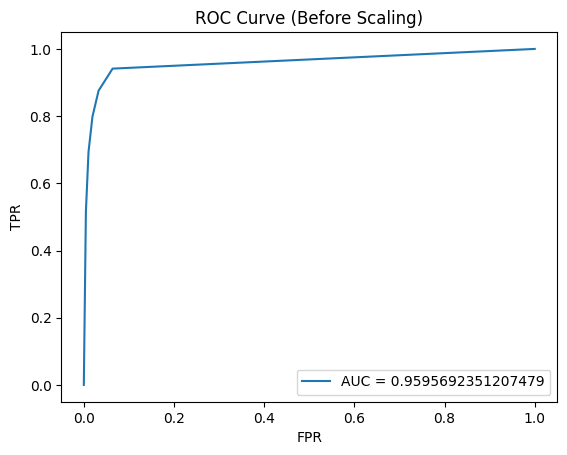

In [ ]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

y_prob = knn.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Before Scaling)")
plt.legend()
plt.show()

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_scaled = knn.predict(X_test)

In [ ]:
print("Accuracy after scaling:", accuracy_score(y_test, y_pred_scaled))

Accuracy after scaling: 0.8344106240451287


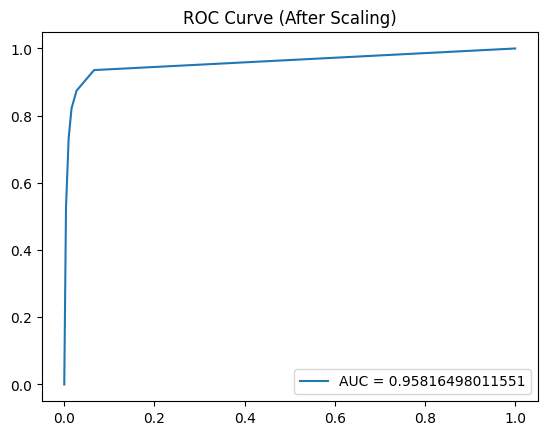

In [ ]:
y_prob_scaled = knn.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob_scaled.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.title("ROC Curve (After Scaling)")
plt.legend()
plt.show()

In [ ]:
from sklearn.utils import resample

df_bal = pd.concat([X, y], axis=1)

safe = df_bal[df_bal[target] == 0]
risky = df_bal[df_bal[target] == 1]

safe_down = resample(safe,
                     replace=False,
                     n_samples=len(risky),
                     random_state=42)

df_balanced = pd.concat([safe_down, risky])

X = df_balanced.drop(target, axis=1)
y = df_balanced[target]

In [ ]:
new_data = {
    'loan_amnt': 35000,
    'term': 60,
    'int_rate': 30.0,
    'installment': 1000,
    'grade': 'G',
    'emp_length': 0,
    'home_ownership': 'RENT',
    'annual_inc': 0,
    'verification_status': 'Not Verified'
}

In [ ]:
new_df = pd.DataFrame([new_data])

In [ ]:
for col in new_df.columns:
    if col in encoders:
        new_df[col] = new_df[col].astype(str)

        # Handle unseen values safely
        new_df[col] = new_df[col].apply(
            lambda x: x if x in encoders[col].classes_ else encoders[col].classes_[0]
        )

        new_df[col] = encoders[col].transform(new_df[col])

In [ ]:
new_df = new_df.reindex(columns=X.columns, fill_value=0)

In [ ]:
# Encode using saved encoders
for col in new_df.columns:
    if col in encoders:
        new_df[col] = new_df[col].astype(str)
        new_df[col] = new_df[col].apply(
            lambda x: x if x in encoders[col].classes_ else encoders[col].classes_[0]
        )
        new_df[col] = encoders[col].transform(new_df[col])

# Align columns
new_df = new_df.reindex(columns=X.columns, fill_value=0)

# 🔥 FIX: ensure numeric
new_df = new_df.apply(pd.to_numeric, errors='coerce')
new_df = new_df.fillna(0)

# Scale
new_scaled = scaler.transform(new_df)

# Predict
prediction = knn.predict(new_scaled)

print("Prediction:", prediction)

Prediction: [5]


In [ ]:
prediction = knn.predict(new_scaled)
print("Prediction:", prediction)

Prediction: [5]


In [ ]:
if prediction[0] == 1:
    print("Loan is Risky (Likely Default)")
else:
    print("Loan is Safe")

Loan is Safe


In [ ]:
print(y.value_counts())

loan_status
0    513
1    513
Name: count, dtype: int64


In [ ]:
print("Class distribution:\n", y.value_counts())

Class distribution:
 loan_status
0    513
1    513
Name: count, dtype: int64
